# new entropy similarity score based on null
## S' = -log_{10}p \times S
## adjust entropy similairty based on p-value

In [1]:
import pickle
import numpy as np


# Load the pickle file
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_negative_entropy_selected_adducts.pkl', 'rb') as f:
    nist_data_neg = pickle.load(f)
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_positive_entropy_selected_adducts.pkl', 'rb') as f:
    nist_data_pos = pickle.load(f)


KeyboardInterrupt: 

In [2]:
# import pickle
# import numpy as np
# with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_negative_entropy_selected_adducts.pkl', 'rb') as f:
#     nist_data = pickle.load(f)

In [ ]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns


def compute_random_similarity(nist_data, num_pairs=100, num_bootstrap=100, subset_size=10000):
    """
    Efficiently compute similarity scores between randomly paired spectra from different compounds,
    using bootstrapping to equalize sample size across spectral entropy groups.

    Parameters:
    nist_data (list): List of spectral dictionaries
    num_pairs (int): Fixed number of random pairs to compare per entropy group per bootstrap iteration
    num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates
    subset_size (int): Number of entries to randomly sample from nist_data for faster processing

    Returns:
    dict: Null distributions of similarity scores grouped by spectral entropy
    """
    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by spectral entropy, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0:
            entropy = me.calculate_spectral_entropy(np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05)
            entropy_groups[round(entropy)].append(spectrum)

    # Precompute valid pairs for each entropy group
    valid_pairs_per_entropy = {}
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair

        spectra_array = np.array(spectra, dtype=object)
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:] if spec1['InChIKey'] != spec2['InChIKey']
        ]

        if valid_pairs:
            valid_pairs_per_entropy[entropy] = valid_pairs

    # Determine the minimum number of valid pairs across all entropy groups
    min_num_pairs = min(len(pairs) for pairs in valid_pairs_per_entropy.values()) if valid_pairs_per_entropy else 0

    # Ensure consistent sample size across entropy groups
    null_distributions = defaultdict(list)
    for entropy, valid_pairs in valid_pairs_per_entropy.items():
        for _ in range(num_bootstrap):
            # Sample with replacement if not enough pairs
            if len(valid_pairs) < min_num_pairs:
                selected_pairs = random.choices(valid_pairs, k=min_num_pairs)
            else:
                selected_pairs = random.sample(valid_pairs, min_num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da=0.05)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)

    return null_distributions


def visualize_null_distributions(null_distributions):
    """
    Visualize null distributions of similarity scores grouped by spectral entropy.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    """
    for entropy, scores in null_distributions.items():
        plt.figure(figsize=(8, 5))
        sns.histplot(scores, kde=True, bins=30, color='blue', alpha=0.6)
        plt.xlabel('Similarity Score')
        plt.ylabel('Frequency')
        plt.title(f'Null Distribution of Similarity Scores (Entropy {entropy})')
        plt.grid(axis='y')
        plt.show()


def calculate_p_value(observed_similarity, null_distribution):
    """
    Calculate one-sided p-value for a similarity score.

    Parameters:
    observed_similarity (float): Similarity score to test
    null_distribution (list or numpy.ndarray): Null distribution of similarity scores

    Returns:
    float: One-sided p-value
    """
    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value


def calculate_p_values_for_all_entropy(null_distributions, observed_similarities):
    """
    Calculate p-values for a given observed similarity score across all entropy groups.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Observed similarity scores grouped by entropy

    Returns:
    dict: P-values for each entropy group
    """
    p_values = {
        entropy: calculate_p_value(observed_similarities[entropy], null_distribution)
        for entropy, null_distribution in null_distributions.items()
        if entropy in observed_similarities
    }
    return p_values


def confidence_weighted_similarity(original_similarity, p_value, min_p=1e-10):
    """
    Compute confidence-weighted similarity score with safeguard against log(0).
    
    Parameters:
    original_similarity (float): The original spectral similarity score
    p_value (float): The p-value derived from the null distribution
    min_p (float): Minimum p-value to prevent log(0) errors
    
    Returns:
    float: Adjusted similarity score
    """
    safe_p_value = max(p_value, min_p)  # Ensure p-value is never 0
    return -np.log10(safe_p_value) * original_similarity


def compute_confidence_weighted_similarity(null_distributions, observed_similarities):
    """
    Compute confidence-weighted similarity scores for a set of observed similarities and normalize them.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Dictionary of observed similarities grouped by spectral entropy

    Returns:
    dict: Normalized confidence-weighted similarity scores
    """
    p_values = calculate_p_values_for_all_entropy(null_distributions, observed_similarities)
    weighted_similarities = {
        entropy: confidence_weighted_similarity(observed_similarities[entropy], p_values[entropy])
        for entropy in observed_similarities if entropy in p_values
    }
    
    # Normalize the scores to range 0-1
    min_val = min(weighted_similarities.values(), default=0)
    max_val = max(weighted_similarities.values(), default=1)  # Prevent division by zero

    if max_val == min_val:  # Prevent NaN when all values are the same
        normalized_similarities = {entropy: 0.5 for entropy in weighted_similarities}  # Assign middle value (0.5)
    else:
        normalized_similarities = {
            entropy: (score - min_val) / (max_val - min_val)
            for entropy, score in weighted_similarities.items()
        }

    return normalized_similarities


In [8]:
nist_data = list(nist_data)
null = compute_random_similarity(nist_data)


In [17]:
# Step 1: Assume observed_similarities is a dictionary of observed similarity scores for each entropy level
# Example structure: observed_similarities = {0: 0.72, 1: 0.65, 2: 0.80, ...}
observed_similarities = {
    entropy: np.random.uniform(0.6, 0.99) for entropy in null.keys()  # Example dummy values
}

# Step 2: Compute p-values for each entropy level
p_values = calculate_p_values_for_all_entropy(null, observed_similarities)

# Step 3: Compute Confidence-Weighted Similarity (this function already normalizes the output)
confidence_weighted_scores = compute_confidence_weighted_similarity(null, observed_similarities)

# Output results
print("Observed Similarities:")
print(observed_similarities)
print("\nP-Values for Observed Similarities:")
print(p_values)
print("\nConfidence-Weighted Similarity Scores (Normalized 0-1):")
print(confidence_weighted_scores)


Observed Similarities:
{1: 0.9308186233592401, 3: 0.7152741753563373, 2: 0.9632956521749703, 0: 0.7338368847669685, 4: 0.7146753019541018, 5: 0.7774852771052776}

P-Values for Observed Similarities:
{1: 0.013958333333333333, 3: 0.08854166666666667, 2: 0.006666666666666667, 0: 0.26166666666666666, 4: 0.2075, 5: 0.4791666666666667}

Confidence-Weighted Similarity Scores (Normalized 0-1):
{1: 0.8000891193184243, 3: 0.2731142314799117, 2: 1.0, 0: 0.09679646737183328, 4: 0.1297180610985474, 5: 0.0}


# 0213 
identity search (+-10mDa)
Use all the data available

In [59]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns


def compute_random_similarity(nist_data, num_bootstrap=100, subset_size=len(nist_data), ms2_tolerance_in_da=0.05):
    """
    Compute similarity scores between randomly paired spectra from different compounds,
    using the maximum amount of available data while maintaining a list output.

    Parameters:
    - nist_data (list): List of spectral dictionaries.
    - num_bootstrap (int): Number of bootstrap iterations (default=100).
    - subset_size (int): Number of entries to randomly sample from nist_data for faster processing (default=100000).
    - ms2_tolerance_in_da (float): Allowed precursor m/z difference for valid comparisons (default ±10 mDa).

    Returns:
    - dict: Dictionary where keys are entropy levels and values are lists of similarity scores.
    - dict: Dictionary where keys are entropy levels and values are the number of valid pairs.
    """

    # Reduce dataset size for efficiency
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by rounded entropy
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        precursor_mz = spectrum.get('precursor_mz')

        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0 and precursor_mz:
            entropy = me.calculate_spectral_entropy(
                np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05
            )
            entropy_groups[round(entropy)].append(spectrum)

    similarity_scores = defaultdict(list)
    valid_pair_counts = {}  # Store the number of valid pairs per entropy group

    # Iterate over entropy groups
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Skip groups with insufficient spectra

        # Convert to NumPy array for faster processing
        spectra_array = np.array(spectra, dtype=object)

        # Precompute all valid pairs with precursor m/z difference ≤ ±10 mDa
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:]
            if spec1['InChIKey'] != spec2['InChIKey'] and abs(spec1['precursor_mz'] - spec2['precursor_mz']) <= 0.01
        ]

        valid_pair_counts[entropy] = len(valid_pairs)  # Store count of valid pairs

        if not valid_pairs:
            continue  # Skip if no valid pairs are available

        # Perform bootstrapping using all valid pairs
        for _ in range(num_bootstrap):
            selected_pairs = random.choices(valid_pairs, k=len(valid_pairs))  # Use all available pairs

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da)
                for spec1, spec2 in selected_pairs
            ]
            similarity_scores[entropy].extend(scores)  # Store all scores instead of averaging

    # Display number of valid pairs per entropy group
    print("Valid Pairs per Entropy Group:")
    for entropy, count in valid_pair_counts.items():
        print(f"Entropy {entropy}: {count} pairs")

    return similarity_scores, valid_pair_counts



def visualize_null_distributions(null_distributions):
    """
    Visualize null distributions of similarity scores grouped by spectral entropy.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    """
    for entropy, scores in null_distributions.items():
        plt.figure(figsize=(8, 5))
        sns.histplot(scores, kde=True, bins=30, color='blue', alpha=0.6)
        plt.xlabel('Similarity Score')
        plt.ylabel('Frequency')
        plt.title(f'Null Distribution of Similarity Scores (Entropy {entropy})')
        plt.grid(axis='y')
        plt.show()


def calculate_p_value(observed_similarity, null_distribution):
    """
    Calculate one-sided p-value for a similarity score.

    Parameters:
    observed_similarity (float): Similarity score to test
    null_distribution (list or numpy.ndarray): Null distribution of similarity scores

    Returns:
    float: One-sided p-value
    """
    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value


def calculate_p_values_for_all_entropy(null_distributions, observed_similarities):
    """
    Calculate p-values for a given observed similarity score across all entropy groups.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Observed similarity scores grouped by entropy

    Returns:
    dict: P-values for each entropy group
    """
    p_values = {
        entropy: calculate_p_value(observed_similarities[entropy], null_distribution)
        for entropy, null_distribution in null_distributions.items()
        if entropy in observed_similarities
    }
    return p_values


def confidence_weighted_similarity(original_similarity, p_value, min_p=1e-10):
    """
    Compute confidence-weighted similarity score with safeguard against log(0).
    
    Parameters:
    original_similarity (float): The original spectral similarity score
    p_value (float): The p-value derived from the null distribution
    min_p (float): Minimum p-value to prevent log(0) errors
    
    Returns:
    float: Adjusted similarity score
    """
    safe_p_value = max(p_value, min_p)  # Ensure p-value is never 0
    return -np.log10(safe_p_value) * original_similarity


def compute_confidence_weighted_similarity(null_distributions, observed_similarities):
    """
    Compute confidence-weighted similarity scores for a set of observed similarities and normalize them.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Dictionary of observed similarities grouped by spectral entropy

    Returns:
    dict: Normalized confidence-weighted similarity scores
    """
    p_values = calculate_p_values_for_all_entropy(null_distributions, observed_similarities)
    weighted_similarities = {
        entropy: confidence_weighted_similarity(observed_similarities[entropy], p_values[entropy])
        for entropy in observed_similarities if entropy in p_values
    }
    
    # Normalize the scores to range 0-1
    min_val = min(weighted_similarities.values(), default=0)
    max_val = max(weighted_similarities.values(), default=1)  # Prevent division by zero

    if max_val == min_val:  # Prevent NaN when all values are the same
        normalized_similarities = {entropy: 0.5 for entropy in weighted_similarities}  # Assign middle value (0.5)
    else:
        normalized_similarities = {
            entropy: (score - min_val) / (max_val - min_val)
            for entropy, score in weighted_similarities.items()
        }

    return normalized_similarities


In [60]:
nist_data = list(nist_data)
null, pairs = compute_random_similarity(nist_data)

KeyboardInterrupt: 

In [ ]:
print(pairs)

In [56]:
# Step 1: Assume observed_similarities is a dictionary of observed similarity scores for each entropy level
# Example structure: observed_similarities = {0: 0.72, 1: 0.65, 2: 0.80, ...}
observed_similarities = {
    entropy: np.random.uniform(0.6, 0.9) for entropy in null.keys()  # Example dummy values
}

# Step 2: Compute p-values for each entropy level
p_values = calculate_p_values_for_all_entropy(null, observed_similarities)

# Step 3: Compute Confidence-Weighted Similarity (this function already normalizes the output)
confidence_weighted_scores = compute_confidence_weighted_similarity(null, observed_similarities)

# Output results
print("Observed Similarities:")
print(observed_similarities)
print("\nP-Values for Observed Similarities:")
print(p_values)
print("\nConfidence-Weighted Similarity Scores (Normalized 0-1):")
print(confidence_weighted_scores)


Observed Similarities:
{1: 0.6006461174271249, 0: 0.8210141933762776, 2: 0.8150148751306154, 3: 0.8204651651278597, 4: 0.8018633971687894, 5: 0.7462194033802876}

P-Values for Observed Similarities:
{1: 0.0, 0: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}

Confidence-Weighted Similarity Scores (Normalized 0-1):
{1: 0.0, 0: 1.0, 2: 0.9727759194709928, 3: 0.9975085853699402, 4: 0.9130963224822684, 5: 0.6605915368011469}


In [57]:
visualize_null_distributions(null)

TypeError: object of type 'numpy.float64' has no len()

<Figure size 576x360 with 0 Axes>

# Look at pairs that have high sim

In [61]:
import numpy as np
import random
from collections import defaultdict
import ms_entropy as me
import pandas as pd


def extract_high_similarity_pairs(nist_data, similarity_threshold=0.8, num_pairs=100, num_bootstrap=100, subset_size=10000, ms2_tolerance_in_da=0.01):
    """
    Extracts high-entropy similarity pairs within each entropy group using bootstrapping and subsetting.

    Parameters:
    - nist_data (list): List of spectral dictionaries.
    - similarity_threshold (float): Minimum entropy similarity score for high-similarity pairs (default=0.8).
    - num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration (default=1000).
    - num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates (default=100).
    - subset_size (int): Number of entries to randomly sample for processing (default=100,000).
    - ms2_tolerance_in_da (float): Allowed precursor m/z difference for valid comparisons (default ±10 mDa).

    Returns:
    - DataFrame with high-similarity pairs and additional metadata.
    """

    # Reduce dataset size for efficiency
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by rounded entropy
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        precursor_mz = spectrum.get('precursor_mz')

        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0 and precursor_mz:
            entropy = me.calculate_spectral_entropy(
                np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05
            )
            entropy_groups[round(entropy)].append(spectrum)

    high_similarity_pairs = defaultdict(set)  # Use a **set** to store unique pairs

    # Iterate over entropy groups
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Skip groups with less than 2 spectra

        # Convert to NumPy array for faster processing
        spectra_array = np.array(spectra, dtype=object)

        # Precompute valid pairs with precursor m/z difference ≤ ±10 mDa
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:]
            if spec1['InChIKey'] != spec2['InChIKey'] and spec1['precursor_mz'] == spec2['precursor_mz']
        ]

        if len(valid_pairs) < num_pairs:
            continue  # Skip if not enough valid pairs

        # Perform bootstrapping
        for _ in range(num_bootstrap):
            selected_pairs = random.sample(valid_pairs, num_pairs)  # Sample `num_pairs` from precomputed list

            for spec1, spec2 in selected_pairs:
                similarity = me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da)

                if similarity >= similarity_threshold:
                    # Ensure consistent ordering (smallest InChIKey first to avoid duplicates)
                    if spec1['InChIKey'] > spec2['InChIKey']:
                        spec1, spec2 = spec2, spec1
                    
                    # Store as a tuple to prevent duplicates
                    pair_key = (
                        entropy, spec1['precursor_mz'], spec2['precursor_mz'],
                        spec1['InChIKey'], spec2['InChIKey'],
                        spec1.get('Name', 'Unknown'), spec2.get('Name', 'Unknown'),
                        spec1.get('Precursor_type', 'Unknown'), spec2.get('Precursor_type', 'Unknown'),
                        spec1.get('Formula', 'Unknown'), spec2.get('Formula', 'Unknown'),
                        len(spec1.get('peaks', [])), len(spec2.get('peaks', [])),  
                        similarity
                    )

                    high_similarity_pairs[entropy].add(pair_key)  # Store in a **set** to avoid duplicates

    # Convert to DataFrame for easy analysis
    high_sim_list = [pair for pairs in high_similarity_pairs.values() for pair in pairs]

    df_high_sim_pairs = pd.DataFrame(
        high_sim_list, 
        columns=['Entropy Group', 'Precursor_mz_1', 'Precursor_mz_2', 
                 'InChIKey_1', 'InChIKey_2', 'Name_1', 'Name_2',
                 'Precursor_type_1', 'Precursor_type_2', 'Formula_1', 'Formula_2',
                 'Num Peaks_1', 'Num Peaks_2', 'Mean Similarity']
    )


    return df_high_sim_pairs



In [62]:
high_sim_pairs = extract_high_similarity_pairs(list(nist_data))

In [52]:
high_sim_pairs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Entropy Group     285 non-null    int64  
 1   Precursor_mz_1    285 non-null    float64
 2   Precursor_mz_2    285 non-null    float64
 3   InChIKey_1        285 non-null    object 
 4   InChIKey_2        285 non-null    object 
 5   Name_1            285 non-null    object 
 6   Name_2            285 non-null    object 
 7   Precursor_type_1  285 non-null    object 
 8   Precursor_type_2  285 non-null    object 
 9   Formula_1         285 non-null    object 
 10  Formula_2         285 non-null    object 
 11  Num Peaks_1       285 non-null    int64  
 12  Num Peaks_2       285 non-null    int64  
 13  Mean Similarity   285 non-null    float64
dtypes: float64(3), int64(3), object(8)
memory usage: 31.3+ KB


In [ ]:
high_sim_pairs.to_csv('high_sim_pairs.csv', index=False)

In [38]:
len(nist_data)

304267

# Exact same precusor mass null

In [70]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

def compute_random_similarity(nist_data, num_pairs=100, num_bootstrap=100, subset_size=10000, ms2_tolerance_in_da=0.05):
    """
    Efficiently compute similarity scores between randomly paired spectra from different compounds,
    using bootstrapping to equalize sample size across spectral entropy groups.

    Parameters:
    - nist_data (list): List of spectral dictionaries
    - num_pairs (int): Fixed number of random pairs to compare per entropy group per bootstrap iteration
    - num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates
    - subset_size (int): Number of entries to randomly sample from nist_data for faster processing
    - ms2_tolerance_in_da (float): Allowed precursor m/z difference for valid comparisons (default ±10 mDa)

    Returns:
    - dict: Null distributions of similarity scores grouped by spectral entropy
    """

    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by rounded entropy, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        precursor_mz = spectrum.get('precursor_mz')

        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0 and precursor_mz:
            entropy = me.calculate_spectral_entropy(np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05)
            entropy_groups[round(entropy)].append(spectrum)

    # Precompute valid pairs for each entropy group
    valid_pairs_per_entropy = {}
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair

        spectra_array = np.array(spectra, dtype=object)
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:]
            if spec1['InChIKey'][:14] != spec2['InChIKey'][:14]  # Compare only first 14 characters of InChIKey
            and spec1['precursor_mz'] == spec2['precursor_mz']  # Ensure precursor m/z matches exactly
        ]

        if valid_pairs:
            valid_pairs_per_entropy[entropy] = valid_pairs

    # Determine the minimum number of valid pairs across all entropy groups
    min_num_pairs = min(len(pairs) for pairs in valid_pairs_per_entropy.values()) if valid_pairs_per_entropy else 0
    min_num_pairs = min(min_num_pairs, num_pairs)  # Ensure we don't exceed the user-defined num_pairs

    # Ensure consistent sample size across entropy groups
    null_distributions = defaultdict(list)
    for entropy, valid_pairs in valid_pairs_per_entropy.items():
        for _ in range(num_bootstrap):
            # Sample with replacement if not enough pairs
            if len(valid_pairs) < min_num_pairs:
                selected_pairs = random.choices(valid_pairs, k=min_num_pairs)
            else:
                selected_pairs = random.sample(valid_pairs, min_num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)

    return null_distributions



def visualize_null_distributions(null_distributions):
    """
    Visualize null distributions of similarity scores grouped by spectral entropy.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    """
    for entropy, scores in null_distributions.items():
        plt.figure(figsize=(8, 5))
        sns.histplot(scores, kde=True, bins=30, color='blue', alpha=0.6)
        plt.xlabel('Similarity Score')
        plt.ylabel('Frequency')
        plt.title(f'Null Distribution of Similarity Scores (Entropy {entropy})')
        plt.grid(axis='y')
        plt.show()


def calculate_p_value(observed_similarity, null_distribution):
    """
    Calculate one-sided p-value for a similarity score.

    Parameters:
    observed_similarity (float): Similarity score to test
    null_distribution (list or numpy.ndarray): Null distribution of similarity scores

    Returns:
    float: One-sided p-value
    """
    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value


def calculate_p_values_for_all_entropy(null_distributions, observed_similarities):
    """
    Calculate p-values for a given observed similarity score across all entropy groups.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Observed similarity scores grouped by entropy

    Returns:
    dict: P-values for each entropy group
    """
    p_values = {
        entropy: calculate_p_value(observed_similarities[entropy], null_distribution)
        for entropy, null_distribution in null_distributions.items()
        if entropy in observed_similarities
    }
    return p_values


def confidence_weighted_similarity(original_similarity, p_value, min_p=1e-10):
    """
    Compute confidence-weighted similarity score with safeguard against log(0).
    
    Parameters:
    original_similarity (float): The original spectral similarity score
    p_value (float): The p-value derived from the null distribution
    min_p (float): Minimum p-value to prevent log(0) errors
    
    Returns:
    float: Adjusted similarity score
    """
    safe_p_value = max(p_value, min_p)  # Ensure p-value is never 0
    return -np.log10(safe_p_value) * original_similarity


def compute_confidence_weighted_similarity(null_distributions, observed_similarities):
    """
    Compute confidence-weighted similarity scores for a set of observed similarities and normalize them.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Dictionary of observed similarities grouped by spectral entropy

    Returns:
    dict: Normalized confidence-weighted similarity scores
    """
    p_values = calculate_p_values_for_all_entropy(null_distributions, observed_similarities)
    weighted_similarities = {
        entropy: confidence_weighted_similarity(observed_similarities[entropy], p_values[entropy])
        for entropy in observed_similarities if entropy in p_values
    }
    
    # Normalize the scores to range 0-1
    min_val = min(weighted_similarities.values(), default=0)
    max_val = max(weighted_similarities.values(), default=1)  # Prevent division by zero

    if max_val == min_val:  # Prevent NaN when all values are the same
        normalized_similarities = {entropy: 0.5 for entropy in weighted_similarities}  # Assign middle value (0.5)
    else:
        normalized_similarities = {
            entropy: (score - min_val) / (max_val - min_val)
            for entropy, score in weighted_similarities.items()
        }

    return normalized_similarities


In [71]:
null = compute_random_similarity(list(nist_data))

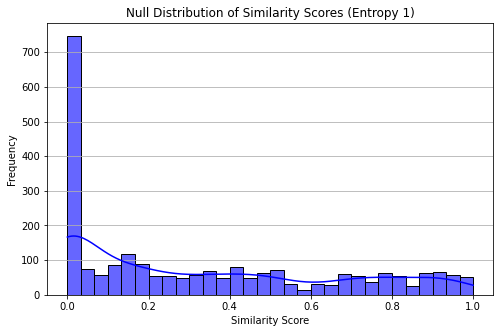

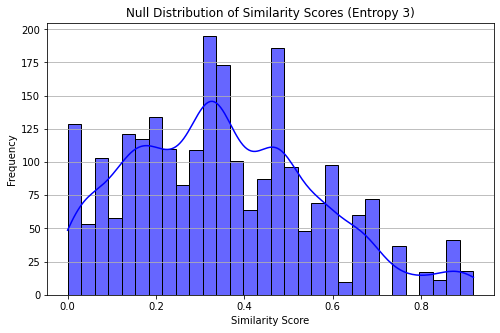

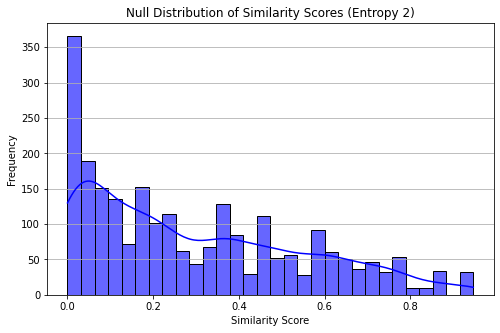

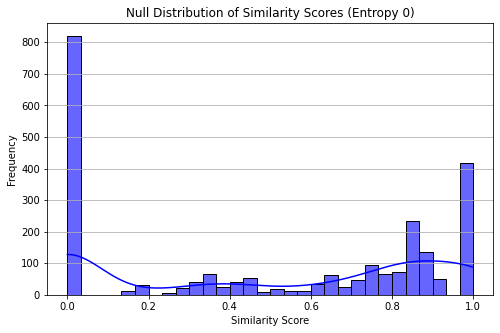

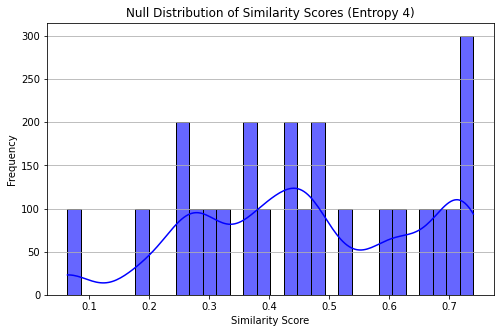

In [72]:
visualize_null_distributions(null)

In [73]:
# Step 1: Assume observed_similarities is a dictionary of observed similarity scores for each entropy level
# Example structure: observed_similarities = {0: 0.72, 1: 0.65, 2: 0.80, ...}
observed_similarities = {
    entropy: np.random.uniform(0.6, 0.99) for entropy in null.keys()  # Example dummy values
}

# Step 2: Compute p-values for each entropy level
p_values = calculate_p_values_for_all_entropy(null, observed_similarities)

# Step 3: Compute Confidence-Weighted Similarity (this function already normalizes the output)
confidence_weighted_scores = compute_confidence_weighted_similarity(null, observed_similarities)

# Output results
print("Observed Similarities:")
print(observed_similarities)
print("\nP-Values for Observed Similarities:")
print(p_values)
print("\nConfidence-Weighted Similarity Scores (Normalized 0-1):")
print(confidence_weighted_scores)


Observed Similarities:
{1: 0.6980129411247347, 3: 0.7384987851372119, 2: 0.9367577188072846, 0: 0.7258554267378912, 4: 0.6728076180669182}

P-Values for Observed Similarities:
{1: 0.19833333333333333, 3: 0.042083333333333334, 2: 0.009583333333333333, 0: 0.4483333333333333, 4: 0.20833333333333334}

Confidence-Weighted Similarity Scores (Normalized 0-1):
{1: 0.1450231521745363, 3: 0.4659538740436329, 2: 1.0, 0: 0.0, 4: 0.12543602413707206}


In [77]:
import numpy as np
import random
from collections import defaultdict
import ms_entropy as me
import pandas as pd


def extract_high_similarity_pairs(nist_data, similarity_threshold=0.8, num_pairs=100, num_bootstrap=100, subset_size=len(nist_data), ms2_tolerance_in_da=0.01):
    """
    Extracts high-entropy similarity pairs within each entropy group using bootstrapping and subsetting.

    Parameters:
    - nist_data (list): List of spectral dictionaries.
    - similarity_threshold (float): Minimum entropy similarity score for high-similarity pairs (default=0.8).
    - num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration (default=1000).
    - num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates (default=100).
    - subset_size (int): Number of entries to randomly sample for processing (default=100,000).
    - ms2_tolerance_in_da (float): Allowed precursor m/z difference for valid comparisons (default ±10 mDa).

    Returns:
    - DataFrame with high-similarity pairs and additional metadata.
    """

    # Reduce dataset size for efficiency
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by rounded entropy
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        precursor_mz = spectrum.get('precursor_mz')

        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0 and precursor_mz:
            entropy = me.calculate_spectral_entropy(
                np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05
            )
            entropy_groups[round(entropy)].append(spectrum)

    high_similarity_pairs = defaultdict(set)  # Use a **set** to store unique pairs

    # Iterate over entropy groups
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Skip groups with less than 2 spectra

        # Convert to NumPy array for faster processing
        spectra_array = np.array(spectra, dtype=object)

        # Precompute valid pairs with precursor m/z difference ≤ ±10 mDa
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:]
            if spec1['InChIKey'] != spec2['InChIKey'] and spec1['precursor_mz'] == spec2['precursor_mz']
        ]

        if len(valid_pairs) < num_pairs:
            continue  # Skip if not enough valid pairs

        # Perform bootstrapping
        for _ in range(num_bootstrap):
            selected_pairs = random.sample(valid_pairs, num_pairs)  # Sample `num_pairs` from precomputed list

            for spec1, spec2 in selected_pairs:
                similarity = me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da)

                if similarity >= similarity_threshold:
                    # Ensure consistent ordering (smallest InChIKey first to avoid duplicates)
                    if spec1['InChIKey'] > spec2['InChIKey']:
                        spec1, spec2 = spec2, spec1
                    
                    # Store as a tuple to prevent duplicates
                    pair_key = (
                        entropy, spec1['precursor_mz'], spec2['precursor_mz'],
                        spec1['InChIKey'], spec2['InChIKey'],
                        spec1.get('Name', 'Unknown'), spec2.get('Name', 'Unknown'),
                        spec1.get('Precursor_type', 'Unknown'), spec2.get('Precursor_type', 'Unknown'),
                        spec1.get('Formula', 'Unknown'), spec2.get('Formula', 'Unknown'),
                        len(spec1.get('peaks', [])), len(spec2.get('peaks', [])),  
                        similarity
                    )

                    high_similarity_pairs[entropy].add(pair_key)  # Store in a **set** to avoid duplicates

    # Convert to DataFrame for easy analysis
    high_sim_list = [pair for pairs in high_similarity_pairs.values() for pair in pairs]

    df_high_sim_pairs = pd.DataFrame(
        high_sim_list, 
        columns=['Entropy Group', 'Precursor_mz_1', 'Precursor_mz_2', 
                 'InChIKey_1', 'InChIKey_2', 'Name_1', 'Name_2',
                 'Precursor_type_1', 'Precursor_type_2', 'Formula_1', 'Formula_2',
                 'Num Peaks_1', 'Num Peaks_2', 'Mean Similarity']
    )


    return df_high_sim_pairs



In [78]:
high_sim_pairs = extract_high_similarity_pairs(list(nist_data))

KeyboardInterrupt: 

In [ ]:
high_sim_pairs.info()

# NIST23 isomer

In [1]:
import pickle
import numpy as np


# Load the pickle file
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_negative_entropy_selected_adducts.pkl', 'rb') as f:
    nist_data_neg = pickle.load(f)
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_positive_entropy_selected_adducts.pkl', 'rb') as f:
    nist_data_pos = pickle.load(f)
    
nist_data_neg = list(nist_data_neg)
nist_data_pos = list(nist_data_pos)

In [2]:
nist_data = nist_data_neg + nist_data_pos

In [4]:
len(list(nist_data))

304267

In [4]:
def remove_duplicate_entries(nist_data):
    """
    Removes duplicate spectra from nist_data based on InChIKey.
    
    Parameters:
    - nist_data (list): List of spectral dictionaries.

    Returns:
    - list: Cleaned list of spectra with unique InChIKeys.
    """

    unique_spectra = {}
    
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        if inchikey and inchikey not in unique_spectra:
            unique_spectra[inchikey] = spectrum  # Store first occurrence
    
    return list(unique_spectra.values())  # Return cleaned list of unique spectra

# Run the function
cleaned_nist_data = remove_duplicate_entries(nist_data)

# Check the size before and after
print(f"Original size: {len(nist_data)}")
print(f"Cleaned size: {len(cleaned_nist_data)}")


Original size: 1197143
Cleaned size: 47827


In [6]:
import itertools
from collections import defaultdict

def select_isomer_pairs(nist_data):
    """
    Identify and select isomeric pairs from NIST data.

    For each spectrum, we require:
      - A valid 'InChIKey'
      - A valid 'precursor_mz'
      - A valid 'Formula'
      
    The function groups spectra by precursor m/z, then by formula. Within
    each formula group, it further groups by the first 14 characters of the
    InChIKey (a common prefix for isomeric compounds) and then checks for pairs
    that have different full InChIKeys.
    
    Stops once 100,000 pairs have been collected.

    Parameters:
    - nist_data (list): List of spectral dictionaries.

    Returns:
    - list: A list of isomer pairs (each pair as a tuple of two spectra).
    """
    
    isomer_pairs = []
    
    # Group spectra by precursor m/z
    precursor_groups = defaultdict(list)
    for spec in nist_data:
        if spec.get('InChIKey') and spec.get('precursor_mz'):
            precursor_groups[spec['precursor_mz']].append(spec)
    
    # Process each precursor m/z group separately
    for precursor, spectra in precursor_groups.items():
        # Group by formula since isomers should have the same formula
        formula_groups = defaultdict(list)
        for spec in spectra:
            formula = spec.get('Formula')
            if formula:
                formula_groups[formula].append(spec)
                
        # Process each formula group
        for formula, group in formula_groups.items():
            if len(group) < 2:
                continue  # Need at least two spectra to form a pair

            # Group by the first 14 characters of InChIKey (the key prefix)
            prefix_groups = defaultdict(list)
            for spec in group:
                # Ensure InChIKey is long enough
                inchi = spec['InChIKey']
                if len(inchi) >= 14:
                    prefix = inchi[:14]
                    prefix_groups[prefix].append(spec)

            # For each prefix group, generate pairs only between spectra with different full InChIKeys
            for prefix, spec_list in prefix_groups.items():
                # Group by full InChIKey
                full_key_groups = defaultdict(list)
                for spec in spec_list:
                    full_key_groups[spec['InChIKey']].append(spec)
                # If all spectra have the same full InChIKey, skip this group.
                if len(full_key_groups) < 2:
                    continue

                # Iterate over pairs of distinct full InChIKey groups
                full_keys = list(full_key_groups.keys())
                for i in range(len(full_keys)):
                    for j in range(i + 1, len(full_keys)):
                        group1 = full_key_groups[full_keys[i]]
                        group2 = full_key_groups[full_keys[j]]
                        # Cross product: all pairs between spectra in the two groups.
                        for spec1 in group1:
                            for spec2 in group2:
                                isomer_pairs.append((spec1, spec2))
                                if len(isomer_pairs) >= max_pairs:
                                    return isomer_pairs
    return isomer_pairs


In [7]:
nist23_isomer = select_isomer_pairs(cleaned_nist_data)

# 1. Prepare Spectral Data

In [ ]:
import pickle
import numpy as np


# Load the pickle file
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_negative_entropy_selected_adducts.pkl', 'rb') as f:
    nist_data_neg = pickle.load(f)
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_positive_entropy_selected_adducts.pkl', 'rb') as f:
    nist_data_pos = pickle.load(f)
    
nist_data_neg = list(nist_data_neg)
nist_data_pos = list(nist_data_pos)

# 2. Select Isomer Pairs

In [23]:
# randomly select a subset
import random

def sample_nist_data(nist_data, sample_size=50000):
    """
    Randomly selects a subset of spectra from the full NIST dataset.

    Parameters:
    - nist_data (list): Full NIST dataset (list of spectral dictionaries).
    - sample_size (int): Number of spectra to randomly select.

    Returns:
    - list: A subset of randomly selected spectra.
    """
    return random.sample(nist_data, min(sample_size, len(nist_data)))


In [20]:
!pip install pubchempy

  Created wheel for pubchempy: filename=PubChemPy-1.0.4-py3-none-any.whl size=13825 sha256=497b268d3ac351eb9aa05c8a455af692aff569f39f727456e2481804883bd356
  Stored in directory: /Users/ellayoung/Library/Caches/pip/wheels/b0/8c/ba/3b00b89931153bf5a4eaa8e73bd1b0319a879cc45175326854
Successfully built pubchempy


In [24]:

from pubchempy import get_compounds
import numpy as np

# Cache to store previously fetched SMILES to avoid redundant API calls
smiles_cache = {}

def inchikey_to_smiles(inchikey):
    """
    Fetch SMILES for a given InChIKey using PubChem.
    Utilizes caching to prevent redundant API calls.

    Args:
        inchikey (str): The InChIKey of the molecule to look up.

    Returns:
        str or np.nan: The fetched isomeric SMILES code, or NaN if not found.
    """
    if inchikey in smiles_cache:
        return smiles_cache[inchikey]  # Return cached SMILES

    # Try full InChIKey lookup
    compounds = get_compounds(inchikey, 'inchikey')
    if len(compounds) > 0:
        smiles = compounds[0].isomeric_smiles
        smiles_cache[inchikey] = smiles
        return smiles

    # Try first 14 characters (first block of InChIKey)
    compounds = get_compounds(inchikey[:14], 'inchikey')
    if len(compounds) > 0:
        smiles = compounds[0].isomeric_smiles
        smiles_cache[inchikey] = smiles
        return smiles

    # If no match found, return NaN and cache the failure
    smiles_cache[inchikey] = np.nan
    return np.nan


In [97]:
!pip install nest_asyncio


In [11]:
import itertools
import time
import joblib
import numpy as np
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem import rdFMCS
from joblib import Parallel, delayed
from pubchempy import get_compounds
import random

# Caching for MCS and SMILES lookups
mcs_cache = {}
smiles_cache = {}

import time
import numpy as np
from pubchempy import get_compounds

# Cache to store previously fetched SMILES
smiles_cache = {}

def inchikey_to_smiles(inchikey):
    """
    Fetch SMILES for a given InChIKey using PubChem, with timing.

    Args:
        inchikey (str): The InChIKey of the molecule to look up.
    
    Returns:
        str: The fetched isomeric SMILES code, or NaN if not found.
    """
    if inchikey in smiles_cache:
        return smiles_cache[inchikey]  # Return cached SMILES

    start_time = time.time()  # Start timer

    # Try full InChIKey lookup
    cc = get_compounds(inchikey, 'inchikey')
    if len(cc) > 0:
        smiles = cc[0].isomeric_smiles
    else:
        # Try first 14 characters of InChIKey
        cc = get_compounds(inchikey[:14], 'inchikey')
        if len(cc) > 0:
            smiles = cc[0].isomeric_smiles
        else:
            smiles = np.nan  # Mark as missing


    smiles_cache[inchikey] = smiles  # Cache result
    return smiles


def one_bond_difference(smiles1, smiles2):
    """
    Determines if two molecules differ by exactly one bond using RDKit MCS analysis.
    Uses caching to avoid redundant calculations.
    """
    if not smiles1 or not smiles2:
        return False
    
    key = tuple(sorted([smiles1, smiles2]))
    if key in mcs_cache:
        return mcs_cache[key]  

    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    if not mol1 or not mol2:
        return False  

    # Run MCS search
    mcs = rdFMCS.FindMCS(
        [mol1, mol2], 
        bondCompare=rdFMCS.BondCompare.CompareAny,  
        matchValences=True  
    )

    if not mcs.smartsString:
        return False  

    common_substructure = Chem.MolFromSmarts(mcs.smartsString)
    if not common_substructure:
        return False  

    num_bonds1 = mol1.GetNumBonds()
    num_bonds2 = mol2.GetNumBonds()
    num_bonds_common = common_substructure.GetNumBonds()

    result = abs(num_bonds1 - num_bonds_common) == 1 and abs(num_bonds2 - num_bonds_common) == 1
    mcs_cache[key] = result  
    return result

def process_isomer_group(spec_list):
    """Processes an isomer group in parallel to identify isomer pairs."""
    isomer_pairs = []
    
    if len(spec_list) < 2:
        return []  

    for spec1, spec2 in itertools.combinations(spec_list, 2):
        if spec1['InChIKey'] == spec2['InChIKey']:
            continue  

        smiles1 = spec1.get('SMILES')
        smiles2 = spec2.get('SMILES')

        if not isinstance(smiles1, str) or not isinstance(smiles2, str):
            continue  

        if one_bond_difference(smiles1, smiles2):
            isomer_pairs.append((spec1, spec2))
    
    return isomer_pairs

def select_isomer_pairs(nist_data, max_pairs=10000, num_jobs=8):
    """Identify and select isomeric pairs from NIST data using parallel processing."""
    start_time = time.time()
    print("⏳ Starting isomer pair selection...")

    isomer_pairs = []

    # Increase dataset size for better results
    subset_size = 10000
    nist_data_subset = random.sample(nist_data, min(subset_size, len(nist_data)))

    # Step 1: Fetch missing SMILES before grouping
    missing_inchikeys = [spec['InChIKey'] for spec in nist_data_subset if 'SMILES' not in spec]
    
    valid_missing_inchikeys = [key for key in missing_inchikeys if isinstance(key, str) and key.strip() != ""]
    
    if valid_missing_inchikeys:
        print(f"🔍 Fetching SMILES for {len(valid_missing_inchikeys)} valid InChIKeys...")
        for key in valid_missing_inchikeys:
            smiles_cache[key] = inchikey_to_smiles(key)  # Fetch and cache each one

    # Step 2: Group spectra by precursor m/z
    precursor_groups = defaultdict(list)
    for spec in nist_data_subset:
        if spec.get('InChIKey') and spec.get('precursor_mz') and spec.get('Formula'):
            if not spec.get('SMILES'):
                spec['SMILES'] = smiles_cache.get(spec['InChIKey'], np.nan)
            if not isinstance(spec['SMILES'], str):  
                continue
            precursor_mz = round(spec['precursor_mz'], 2)
            precursor_groups[precursor_mz].append(spec)

    print(f"📊 Grouped {len(nist_data_subset)} spectra into {len(precursor_groups)} precursor m/z groups.")

    grouped_specs = []
    
    # Step 3: Group by first 14 characters of InChIKey
    for precursor, spectra in precursor_groups.items():
        prefix_groups = defaultdict(list)
        for spec in spectra:
            prefix = spec['InChIKey'][:14]  
            prefix_groups[prefix].append(spec)

        for prefix, spec_list in prefix_groups.items():
            if len(spec_list) > 1:
                grouped_specs.append(spec_list)

    print(f"✅ Valid groups for processing: {len(grouped_specs)}")

    # Step 4: Run isomer pair selection in parallel
    results = Parallel(n_jobs=num_jobs, backend="loky", batch_size=50)(
        delayed(process_isomer_group)(group) for group in grouped_specs
    )

    for res in results:
        isomer_pairs.extend(res)
        if len(isomer_pairs) >= max_pairs:
            print(f"✅ Reached {max_pairs} pairs, stopping early.")
            return isomer_pairs[:max_pairs]

    print(f"✅ Found {len(isomer_pairs)} isomer pairs in {time.time() - start_time:.2f} sec.")
    return isomer_pairs[:max_pairs]


In [ ]:
import random

nist_data = list(nist_data)
subset_size = 10000  # Change this value based on available memory and speed
nist_data_subset = random.sample(nist_data, min(subset_size, len(nist_data)))

print(f"✅ Subset created: {len(nist_data_subset)} spectra selected.")

nist23_isomer = select_isomer_pairs(nist_data_subset, max_pairs=1, num_jobs=8)
print(f"Final isomer pairs count: {len(nist23_isomer)}")


# 3. Compute Entropy Similarity for Isomer Pairs

# 4. Compute Null-Adjusted Entropy Similarity

In [28]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(0)

def compute_random_similarity(nist_data, num_pairs=100, num_bootstrap=100, subset_size=10000, ms2_tolerance_in_da=0.05):
    """
    Efficiently compute similarity scores between randomly paired spectra from different compounds,
    using bootstrapping to stabilize similarity estimates.

    Parameters:
    - nist_data (list): List of spectral dictionaries
    - num_pairs (int): Minimum number of random pairs to compare per entropy group per bootstrap iteration
    - num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates
    - subset_size (int): Number of entries to randomly sample from nist_data for faster processing
    - ms2_tolerance_in_da (float): Allowed precursor m/z difference for valid comparisons (default ±10 mDa)

    Returns:
    - dict: Null distributions of similarity scores grouped by spectral entropy
    """

    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by rounded entropy, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        precursor_mz = spectrum.get('precursor_mz')

        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0 and precursor_mz:
            entropy = me.calculate_spectral_entropy(np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05)
            entropy_groups[round(entropy)].append(spectrum)

    # Precompute valid pairs for each entropy group
    valid_pairs_per_entropy = {}
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair

        spectra_array = np.array(spectra, dtype=object)
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:]
            if abs(spec1['precursor_mz'] - spec2['precursor_mz']) <= 0.02  # Allow small m/z variation
            and spec1['InChIKey'][:14] != spec2['InChIKey'][:14]  # Ensure chemically different
        ]

        if valid_pairs:
            valid_pairs_per_entropy[entropy] = valid_pairs

    # Compute null distributions, keeping all available pairs and only up-sampling when needed
    null_distributions = defaultdict(list)
    for entropy, valid_pairs in valid_pairs_per_entropy.items():
        for _ in range(num_bootstrap):
            if len(valid_pairs) < num_pairs:
                # If too few pairs, up-sample with replacement
                selected_pairs = random.choices(valid_pairs, k=num_pairs)
            else:
                # Keep all available pairs (no downsampling)
                selected_pairs = valid_pairs  

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)

    return null_distributions


def visualize_null_distributions(null_distributions):
    """
    Visualize null distributions of similarity scores grouped by spectral entropy.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    """
    for entropy, scores in null_distributions.items():
        plt.figure(figsize=(8, 5))
        sns.histplot(scores, kde=True, bins=30, color='blue', alpha=0.6)
        plt.xlabel('Similarity Score')
        plt.ylabel('Frequency')
        plt.title(f'Null Distribution of Similarity Scores (Entropy {entropy})')
        plt.grid(axis='y')
        plt.show()


def calculate_p_value(observed_similarity, null_distribution):
    """
    Calculate one-sided p-value for a similarity score.

    Parameters:
    observed_similarity (float): Similarity score to test
    null_distribution (list or numpy.ndarray): Null distribution of similarity scores

    Returns:
    float: One-sided p-value
    """
    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value


def calculate_p_values_for_all_entropy(null_distributions, observed_similarities):
    """
    Calculate p-values for a given observed similarity score across all entropy groups.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Observed similarity scores grouped by entropy

    Returns:
    dict: P-values for each entropy group
    """
    p_values = {
        entropy: calculate_p_value(observed_similarities[entropy], null_distribution)
        for entropy, null_distribution in null_distributions.items()
        if entropy in observed_similarities
    }
    return p_values


def confidence_weighted_similarity(original_similarity, p_value, min_p=1e-10):
    """
    Compute confidence-weighted similarity score with safeguard against log(0).
    
    Parameters:
    original_similarity (float): The original spectral similarity score
    p_value (float): The p-value derived from the null distribution
    min_p (float): Minimum p-value to prevent log(0) errors
    
    Returns:
    float: Adjusted similarity score
    """
    safe_p_value = max(p_value, min_p)  # Ensure p-value is never 0
    return -np.log10(safe_p_value) * original_similarity


def compute_confidence_weighted_similarity(null_distributions, observed_similarities):
    """
    Compute confidence-weighted similarity scores for a set of observed similarities and normalize them.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Dictionary of observed similarities grouped by spectral entropy

    Returns:
    dict: Normalized confidence-weighted similarity scores
    """
    p_values = calculate_p_values_for_all_entropy(null_distributions, observed_similarities)
    weighted_similarities = {
        entropy: confidence_weighted_similarity(observed_similarities[entropy], p_values[entropy])
        for entropy in observed_similarities if entropy in p_values
    }
    
    # Normalize the scores to range 0-1
    min_val = min(weighted_similarities.values(), default=0)
    max_val = max(weighted_similarities.values(), default=1)  # Prevent division by zero

    if max_val == min_val:  # Prevent NaN when all values are the same
        normalized_similarities = {entropy: 0.5 for entropy in weighted_similarities}  # Assign middle value (0.5)
    else:
        normalized_similarities = {
            entropy: (score - min_val) / (max_val - min_val)
            for entropy, score in weighted_similarities.items()
        }

    return normalized_similarities


In [29]:
null = compute_random_similarity(nist_data)

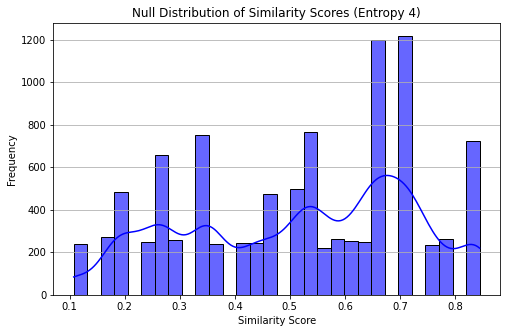

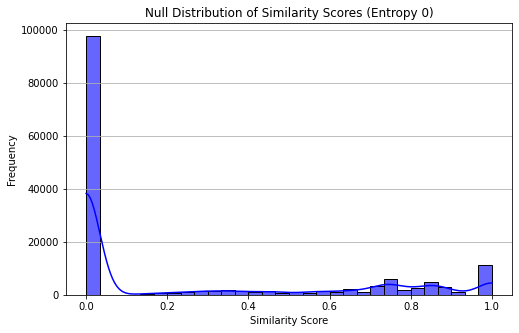

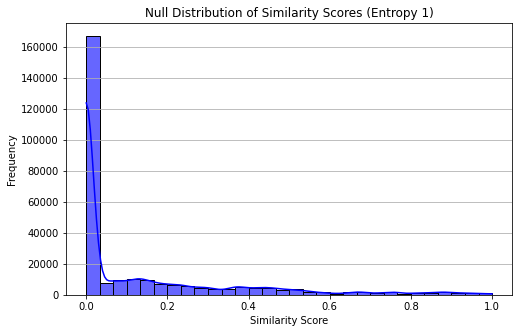

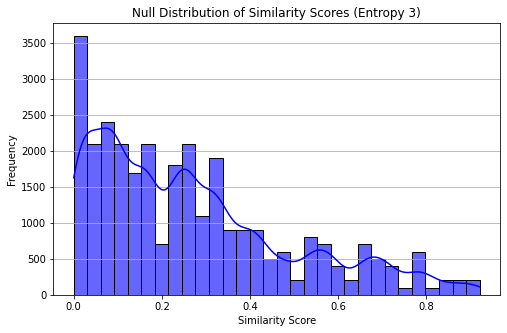

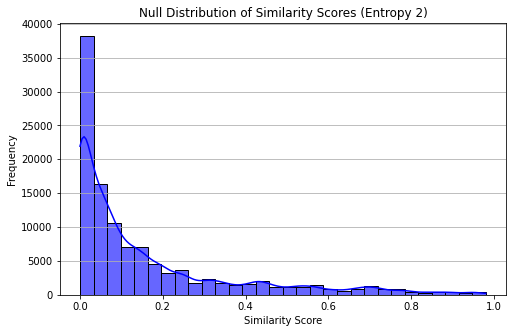

In [30]:
visualize_null_distributions(null)

In [47]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import gaussian_kde

# # ✅ Ensure you have a valid null distribution dictionary: {entropy_level: list_of_similarity_scores}

# def calculate_p_value_empirical(observed_similarity, null_distribution):
#     """
#     Compute a one-sided p-value using simple fraction counting.
#     """
#     return np.mean(np.array(null_distribution) >= observed_similarity)

# def calculate_p_value_kde(observed_similarity, null_distribution):
#     """
#     Compute a one-sided p-value using Kernel Density Estimation (KDE).
#     """
#     if len(null_distribution) < 10:  # If too few samples, fall back to empirical
#         return calculate_p_value_empirical(observed_similarity, null_distribution)

#     kde = gaussian_kde(null_distribution)  # Fit KDE to the null distribution
#     return kde.integrate_box_1d(observed_similarity, np.max(null_distribution))



In [34]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import pandas as pd

def compute_random_similarity(nist_data, num_pairs=100, num_bootstrap=100, subset_size=10000, ms2_tolerance_in_da=0.05):
    """
    Compute similarity scores between randomly paired spectra from different compounds,
    using bootstrapping to stabilize similarity estimates.

    Parameters:
    - nist_data (list): List of spectral dictionaries
    - num_pairs (int): Minimum number of random pairs to compare per entropy group per bootstrap iteration
    - num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates
    - subset_size (int): Number of entries to randomly sample from nist_data for faster processing
    - ms2_tolerance_in_da (float): Allowed precursor m/z difference for valid comparisons (default ±10 mDa)

    Returns:
    - dict: Null distributions of similarity scores grouped by spectral entropy
    - DataFrames: Summary and detailed pairwise comparison data
    """

    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by rounded entropy, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        precursor_mz = spectrum.get('precursor_mz')

        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0 and precursor_mz:
            entropy = me.calculate_spectral_entropy(np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05)
            spectrum['entropy'] = entropy  # Store entropy for each spectrum
            entropy_groups[round(entropy)].append(spectrum)

    # Precompute valid pairs for each entropy group
    valid_pairs_per_entropy = {}
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair

        spectra_array = np.array(spectra, dtype=object)
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:]
            if abs(spec1['precursor_mz'] - spec2['precursor_mz']) <= ms2_tolerance_in_da  # Allow small m/z variation
            and spec1['InChIKey'][:14] != spec2['InChIKey'][:14]  # Ensure chemically different
        ]

        if valid_pairs:
            valid_pairs_per_entropy[entropy] = valid_pairs

    # Compute null distributions, keeping all available pairs and only up-sampling when needed
    null_distributions = defaultdict(list)
    detailed_comparisons = []  # List to store pairwise comparison details

    for entropy, valid_pairs in valid_pairs_per_entropy.items():
        for bootstrap_iter in range(1, num_bootstrap + 1):
            if len(valid_pairs) < num_pairs:
                # If too few pairs, up-sample with replacement
                selected_pairs = random.choices(valid_pairs, k=num_pairs)
            else:
                # Keep all available pairs (no downsampling)
                selected_pairs = valid_pairs  

            for spec1, spec2 in selected_pairs:
                similarity_score = me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da)
                null_distributions[entropy].append(similarity_score)

                # Store pairwise details
                detailed_comparisons.append({
                    "Entropy Group": entropy,
                    "Spectrum 1 id": spec1['Name'],
                    "Spectrum 2 id": spec2['Name'],
                    "Precursor m/z (Spec 1)": spec1['precursor_mz'],
                    "Precursor m/z (Spec 2)": spec2['precursor_mz'],
                    "InChIKey Prefix (Spec 1)": spec1['InChIKey'][:14],
                    "InChIKey Prefix (Spec 2)": spec2['InChIKey'][:14],
                    "Spectral Entropy (Spec 1)": spec1['entropy'],
                    "Spectral Entropy (Spec 2)": spec2['entropy'],
                    "Similarity Score": similarity_score,
                    "Bootstrap Iteration": bootstrap_iter
                })

    # Create DataFrames for CSV output
    summary_data = [{"Entropy Group": entropy, "Total Comparisons": len(pairs)} for entropy, pairs in valid_pairs_per_entropy.items()]
    summary_df = pd.DataFrame(summary_data)

    detailed_df = pd.DataFrame(detailed_comparisons)

    # Save to CSV
    summary_df.to_csv("entropy_comparison_summary.csv", index=False)
    detailed_df.to_csv("entropy_comparison_details.csv", index=False)

    return null_distributions, summary_df, detailed_df


In [35]:
# null_distributions, summary_df, detailed_df = compute_random_similarity(nist_data)


In [33]:
nist_data[1]

{'Name': 'Ethylphosphonic acid',
 'Precursor_type': '[M-H-H2O]-',
 'Instrument_type': 'HCD',
 'Instrument': 'Thermo Finnigan Elite Orbitrap',
 'Ionization': 'ESI',
 'In-source_voltage': None,
 'Collision_gas': 'N2',
 'Collision_energy': 'NCE=75% 7eV',
 'Ion_mode': 'N',
 'InChIKey': 'GATNOFPXSDHULC-UHFFFAOYSA-N',
 'Formula': 'C2H7O3P',
 'MW': 110.0,
 'ExactMass': 110.013281,
 'CAS#': '6779-09-5',
 'NIST#': '1189640',
 'Num Peaks': 2,
 'precursor_mz': 90.9954,
 'peaks': array([[62.9645,  1.    ]], dtype=float32),
 'fragment_annotation': ['PO2/5.7pp', 'p/2.9pp']}

In [ ]:
# fanzhou's idea
# for each elution time block, cnonfidence interval
# for each chemical class, different retention time confidence interval

In [37]:


def calculate_p_value(observed_similarity, null_distribution):
    """
    Calculate one-sided p-value for a similarity score.

    Parameters:
    observed_similarity (float): Similarity score to test
    null_distribution (list or numpy.ndarray): Null distribution of similarity scores

    Returns:
    float: One-sided p-value
    """
    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value


def calculate_p_values_for_all_entropy(null_distributions, observed_similarities):
    """
    Calculate p-values for a given observed similarity score across all entropy groups.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Observed similarity scores grouped by entropy

    Returns:
    dict: P-values for each entropy group
    """
    p_values = {
        entropy: calculate_p_value(observed_similarities[entropy], null_distribution)
        for entropy, null_distribution in null_distributions.items()
        if entropy in observed_similarities
    }
    return p_values


def confidence_weighted_similarity(original_similarity, p_value, min_p=1e-10):
    """
    Compute confidence-weighted similarity score with safeguard against log(0).
    
    Parameters:
    original_similarity (float): The original spectral similarity score
    p_value (float): The p-value derived from the null distribution
    min_p (float): Minimum p-value to prevent log(0) errors
    
    Returns:
    float: Adjusted similarity score
    """
    safe_p_value = max(p_value, min_p)  # Ensure p-value is never 0
    return -np.log10(safe_p_value) * original_similarity


def compute_confidence_weighted_similarity(null_distributions, observed_similarities):
    """
    Compute confidence-weighted similarity scores for a set of observed similarities and normalize them.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarities (dict): Dictionary of observed similarities grouped by spectral entropy

    Returns:
    dict: Normalized confidence-weighted similarity scores
    """
    p_values = calculate_p_values_for_all_entropy(null_distributions, observed_similarities)
    weighted_similarities = {
        entropy: confidence_weighted_similarity(observed_similarities[entropy], p_values[entropy])
        for entropy in observed_similarities if entropy in p_values
    }
    
    # Normalize the scores to range 0-1
    min_val = min(weighted_similarities.values(), default=0)
    max_val = max(weighted_similarities.values(), default=1)  # Prevent division by zero

    if max_val == min_val:  # Prevent NaN when all values are the same
        normalized_similarities = {entropy: 0.5 for entropy in weighted_similarities}  # Assign middle value (0.5)
    else:
        normalized_similarities = {
            entropy: (score - min_val) / (max_val - min_val)
            for entropy, score in weighted_similarities.items()
        }

    return normalized_similarities
